In [32]:
import pandas as pd

import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel('../data/BTX_17-23_Yearly_Totals.xlsx', sheet_name = 0)

df.head(10)

,Full Date,Credit Cards BTX,Credit Card Supp,Credit Card IP,Cash BTX,Cash Supp,Cash IP,Check BTX,Check Supp,Check IP
0,2017-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2017-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2017-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2017-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2017-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2017-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2017-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2017-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2017-01-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2017-01-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
#Find out how many NaN or Null are in sheet 0

print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(365, 10)
Full Date           datetime64[ns]
Credit Cards BTX           float64
Credit Card Supp           float64
Credit Card IP             float64
Cash BTX                   float64
Cash Supp                  float64
Cash IP                    float64
Check BTX                  float64
Check Supp                 float64
Check IP                   float64
dtype: object
Full Date             0
Credit Cards BTX    202
Credit Card Supp    342
Credit Card IP      288
Cash BTX            353
Cash Supp           362
Cash IP             363
Check BTX           365
Check Supp          365
Check IP            361
dtype: int64


In [7]:
# Combining all sheets together

all_sheets = pd.read_excel('../data/BTX_17-23_Yearly_Totals.xlsx', sheet_name = None)

print(all_sheets.keys())

dict_keys(['2017', '2018', '2019', '2020', '2021', '2022', '2023'])


In [12]:
# Adding the Sheet Name (2017 - 2023) to all the columns

dfs = []

for year, sheet in all_sheets.items():
    sheet['year'] = year
    dfs.append(sheet)

df_all = pd.concat(dfs, ignore_index = True)

print(df_all.shape)
print(df_all.head())

(2556, 15)
   Full Date  Credit Cards BTX  Credit Card Supp  Credit Card IP  Cash BTX  \
0 2017-01-01               NaN               NaN             NaN       NaN   
1 2017-01-02               NaN               NaN             NaN       NaN   
2 2017-01-03               NaN               NaN             NaN       NaN   
3 2017-01-04               NaN               NaN             NaN       NaN   
4 2017-01-05               NaN               NaN             NaN       NaN   

   Cash Supp  Cash IP  Check BTX  Check Supp  Check IP  year  Credit Card BTX  \
0        NaN      NaN        NaN         NaN       NaN  2017              NaN   
1        NaN      NaN        NaN         NaN       NaN  2017              NaN   
2        NaN      NaN        NaN         NaN       NaN  2017              NaN   
3        NaN      NaN        NaN         NaN       NaN  2017              NaN   
4        NaN      NaN        NaN         NaN       NaN  2017              NaN   

   Credit Card WL  Cash WL  Check

In [10]:
type(all_sheets['2017'])

pandas.core.frame.DataFrame

In [13]:
# Got an unexpected result from df_all.shape. 
# Found an 's' was dropped from Credit Card BTX, and the WL replaced IP all in 2020

for year, sheet in all_sheets.items():
    print(year, sheet.columns.tolist())

2017 ['Full Date', 'Credit Cards BTX', 'Credit Card Supp', 'Credit Card IP', 'Cash BTX', 'Cash Supp', 'Cash IP', 'Check BTX', 'Check Supp', 'Check IP', 'year']
2018 ['Full Date', 'Credit Cards BTX', 'Credit Card Supp', 'Credit Card IP', 'Cash BTX', 'Cash Supp', 'Cash IP', 'Check BTX', 'Check Supp', 'Check IP', 'year']
2019 ['Full Date', 'Credit Cards BTX', 'Credit Card Supp', 'Credit Card IP', 'Cash BTX', 'Cash Supp', 'Cash IP', 'Check BTX', 'Check Supp', 'Check IP', 'year']
2020 ['Full Date', 'Credit Card BTX', 'Credit Card Supp', 'Credit Card WL', 'Cash BTX', 'Cash Supp', 'Cash WL', 'Check BTX', 'Check Supp', 'Check WL', 'year']
2021 ['Full Date', 'Credit Card BTX', 'Credit Card Supp', 'Credit Card WL', 'Cash BTX', 'Cash Supp', 'Cash WL', 'Check BTX', 'Check Supp', 'Check WL', 'year']
2022 ['Full Date', 'Credit Card BTX', 'Credit Card Supp', 'Credit Card WL', 'Cash BTX', 'Cash Supp', 'Cash WL', 'Check BTX', 'Check Supp', 'Check WL', 'year']
2023 ['Full Date', 'Credit Card BTX', 'Cred

In [18]:
# Standardizing Column Names 

standard_columns = {
    'Full Date': 'full_date',
    'Credit Cards BTX': 'cc_btx',
    'Credit Card BTX': 'cc_btx', 
    'Credit Card Supp': 'cc_supp',
    'Credit Card IP': 'cc_wl',
    'Credit Card WL': 'cc_wl',
    'Cash BTX': 'cash_btx',
    'Cash Supp': 'cash_supp',
    'Cash IP': 'cash_wl',
    'Cash WL': 'cash_wl',
    'Check BTX': 'check_btx',
    'Check Supp': 'check_supp',
    'Check IP': 'check_wl',
    'Check WL': 'check_wl',
}

dfs = []

for year, sheet in all_sheets.items():
    sheet = sheet.rename(columns = standard_columns)
    sheet['year'] = year
    dfs.append(sheet)

df_all = pd.concat(dfs, ignore_index = True)

print(df_all.shape)
print(df_all.columns.tolist())

(2556, 11)
['full_date', 'cc_btx', 'cc_supp', 'cc_wl', 'cash_btx', 'cash_supp', 'cash_wl', 'check_btx', 'check_supp', 'check_wl', 'year']


The Cells above did the following:  

Identified inconsistent column names across 7 years of data.

Built a mapping to standardize them.

Looped through all sheets and applied it.

Stacked everything into one clean combined dataset.

In [19]:
# Fill NaN values with 0
df_all = df_all.fillna(0)

print(df_all.isnull().sum())

full_date     0
cc_btx        0
cc_supp       0
cc_wl         0
cash_btx      0
cash_supp     0
cash_wl       0
check_btx     0
check_supp    0
check_wl      0
year          0
dtype: int64


In [20]:
print(df_all.dtypes)
print(df_all.head())
print(df_all.tail())

full_date     datetime64[ns]
cc_btx               float64
cc_supp              float64
cc_wl                float64
cash_btx             float64
cash_supp            float64
cash_wl              float64
check_btx            float64
check_supp           float64
check_wl             float64
year                  object
dtype: object
   full_date  cc_btx  cc_supp  cc_wl  cash_btx  cash_supp  cash_wl  check_btx  \
0 2017-01-01     0.0      0.0    0.0       0.0        0.0      0.0        0.0   
1 2017-01-02     0.0      0.0    0.0       0.0        0.0      0.0        0.0   
2 2017-01-03     0.0      0.0    0.0       0.0        0.0      0.0        0.0   
3 2017-01-04     0.0      0.0    0.0       0.0        0.0      0.0        0.0   
4 2017-01-05     0.0      0.0    0.0       0.0        0.0      0.0        0.0   

   check_supp  check_wl  year  
0         0.0       0.0  2017  
1         0.0       0.0  2017  
2         0.0       0.0  2017  
3         0.0       0.0  2017  
4         0.0       

In [22]:
# Add useful time columns
df_all['month'] = df_all['full_date'].dt.month
df_all['month_name'] = df_all['full_date'].dt.strftime('%B')
df_all['day_of_week'] = df_all['full_date'].dt.day_name()
df_all['quarter'] = df_all['full_date'].dt.quarter

# Add a total revenue column per day
df_all['total_revenue'] = df_all[['cc_btx', 'cc_supp', 'cc_wl', 
                                    'cash_btx', 'cash_supp', 'cash_wl',
                                    'check_btx', 'check_supp', 'check_wl']].sum(axis=1)

print(df_all[['full_date', 'year', 'month', 'day_of_week', 'total_revenue']].head(10))


   full_date  year  month day_of_week  total_revenue
0 2017-01-01  2017      1      Sunday            0.0
1 2017-01-02  2017      1      Monday            0.0
2 2017-01-03  2017      1     Tuesday            0.0
3 2017-01-04  2017      1   Wednesday            0.0
4 2017-01-05  2017      1    Thursday            0.0
5 2017-01-06  2017      1      Friday            0.0
6 2017-01-07  2017      1    Saturday            0.0
7 2017-01-08  2017      1      Sunday            0.0
8 2017-01-09  2017      1      Monday            0.0
9 2017-01-10  2017      1     Tuesday            0.0


In [23]:
df_all.to_csv('../data/clinic_revenue_clean.csv', index = False)

In [25]:
df_all.tail()

,full_date,cc_btx,cc_supp,cc_wl,cash_btx,cash_supp,cash_wl,check_btx,check_supp,check_wl,year,month,month_name,day_of_week,quarter,total_revenue
2551,2023-12-27,916.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023,12,December,Wednesday,4,916.0
2552,2023-12-28,369.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023,12,December,Thursday,4,369.0
2553,2023-12-29,613.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023,12,December,Friday,4,613.0
2554,2023-12-30,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023,12,December,Saturday,4,0.0
2555,2023-12-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023,12,December,Sunday,4,0.0


In [28]:
yearly_revenue = df_all.groupby('year')['total_revenue'].sum()

print(yearly_revenue)

year
2017     48974.670
2018    125416.196
2019    162116.120
2020    152439.580
2021    158357.850
2022    187025.000
2023    170201.430
Name: total_revenue, dtype: float64


In [29]:
df_all.groupby('year')['total_revenue'].describe()


,count,mean,std,min,25%,50%,75%,max
year,,,,,,,,
2017,365.0,134.177178,223.216909,0.0,0.00,0.0,211.9200,2039.84
2018,365.0,343.606016,319.314600,0.0,119.92,299.8,493.7500,2325.80
2019,365.0,444.153753,367.551963,0.0,195.00,389.0,654.0000,3357.00
2020,366.0,416.501585,399.589729,0.0,163.00,358.0,607.6875,4849.00
2021,365.0,433.857123,548.594104,0.0,149.00,373.0,567.0000,6687.00
2022,365.0,512.397260,871.259331,0.0,165.00,416.0,644.0000,10619.00
2023,365.0,466.305288,568.658057,0.0,212.00,369.0,576.0000,5722.18


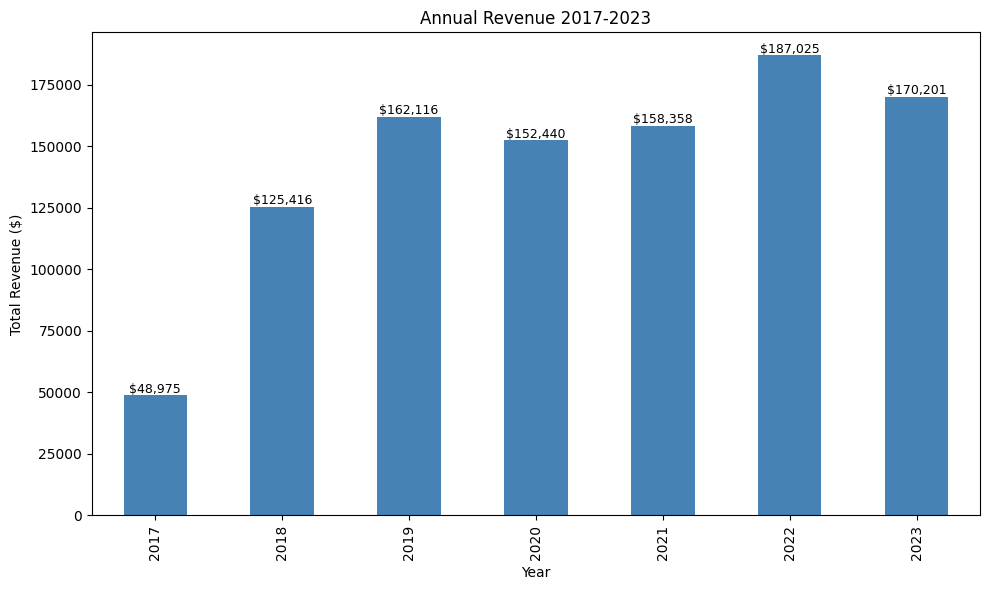

In [35]:
fig, ax = plt.subplots(figsize=(10,6))
bars = yearly_revenue.plot(kind='bar', ax=ax, color='steelblue')

# Add value labels on top of each bar
for i, val in enumerate(yearly_revenue):
    ax.text(i, val + 1000, f'${val:,.0f}', ha='center', fontsize=9)

ax.set_title('Annual Revenue 2017-2023')
ax.set_xlabel('Year')
ax.set_ylabel('Total Revenue ($)')
plt.tight_layout()
plt.show()

In [36]:
# Find YoY Growth

yoy_growth = yearly_revenue.pct_change() * 100
print(yoy_growth.round(1))

year
2017      NaN
2018    156.1
2019     29.3
2020     -6.0
2021      3.9
2022     18.1
2023     -9.0
Name: total_revenue, dtype: float64


In [39]:
df_2023 = df_all[df_all['year'] == '2023']
monthly_2023 = df_2023.groupby('month')['total_revenue'].sum()
print(monthly_2023)


month
1     12151.00
2     16311.75
3     11969.00
4     13497.00
5     11674.00
6     13369.00
7     17079.00
8     25932.68
9      9185.00
10    13713.00
11    13134.00
12    12186.00
Name: total_revenue, dtype: float64


In [38]:
df_2023.head()

,full_date,cc_btx,cc_supp,cc_wl,cash_btx,cash_supp,cash_wl,check_btx,check_supp,check_wl,year,month,month_name,day_of_week,quarter,total_revenue
2191,2023-01-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023,1,January,Sunday,1,0.0
2192,2023-01-02,335.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023,1,January,Monday,1,335.0
2193,2023-01-03,178.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023,1,January,Tuesday,1,178.0
2194,2023-01-04,1039.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023,1,January,Wednesday,1,1039.0
2195,2023-01-05,649.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023,1,January,Thursday,1,649.0


In [40]:
# August was abnormally high, lets investigate

august_2023 = df_all[(df_all['year'] == '2023') & (df_all['month'] == 8)]
print(august_2023[['full_date', 'total_revenue']].sort_values('total_revenue', ascending=False).head(10))

      full_date  total_revenue
2416 2023-08-14        5722.18
2433 2023-08-31        3691.00
2422 2023-08-20        2180.50
2425 2023-08-23        1909.00
2432 2023-08-30         949.00
2407 2023-08-05         930.00
2406 2023-08-04         827.00
2417 2023-08-15         675.00
2414 2023-08-12         669.00
2430 2023-08-28         547.00


In [ ]:
# August 14th was the biggest